# CopulAX Examples
## Archimedean Copula Distributions

CopulAX provides Archimedean copula distribution objects with a standardized interface for density evaluation, sampling, CDF computation, and parameter fitting. This notebook demonstrates all six Archimedean copulas:

- **Clayton** — lower tail dependence, θ ∈ (0, ∞)
- **Frank** — symmetric dependence (allows negative), θ ∈ ℝ \ {0}
- **Gumbel** — upper tail dependence, θ ∈ [1, ∞)
- **Joe** — upper tail dependence, θ ∈ [1, ∞)
- **AMH** (Ali-Mikhail-Haq) — weak dependence (d ≤ 2 only), θ ∈ [-1, 1)
- **Independence** — no dependence (null/benchmark model), no parameters

Each copula is defined by a **generator function** φ(t) and its inverse ψ(s), such that:

$$C(u_1, \ldots, u_d) = \psi(\phi(u_1) + \cdots + \phi(u_d))$$

In [1]:
import jax
import jax.numpy as jnp
from jax.random import split
from copulax import get_random_key
from copulax.copulas import (
    clayton_copula,
    frank_copula,
    gumbel_copula,
    joe_copula,
    amh_copula,
    independence_copula,
)

key = get_random_key()

## Parameter Specification

Archimedean copula objects use Python dictionaries for parameter specification. The `example_params()` method returns a valid parameter dictionary containing univariate marginal distributions and copula-specific parameters.

For copulas with a dependence parameter θ, the `copula` key contains `{'theta': value}`. The independence copula has no parameters, so its `copula` key is an empty dict `{}`.

In [2]:
# 3D copulas
print("Clayton params:", clayton_copula.example_params(dim=3))
print()
print("Independence params:", independence_copula.example_params(dim=3))

Clayton params: {'marginals': ((Normal, {'mu': Array(0., dtype=float32), 'sigma': Array(1., dtype=float32)}), (Normal, {'mu': Array(0., dtype=float32), 'sigma': Array(1., dtype=float32)}), (Normal, {'mu': Array(0., dtype=float32), 'sigma': Array(1., dtype=float32)})), 'copula': {'theta': Array(2., dtype=float32)}}

Independence params: {'marginals': ((Normal, {'mu': Array(0., dtype=float32), 'sigma': Array(1., dtype=float32)}), (Normal, {'mu': Array(0., dtype=float32), 'sigma': Array(1., dtype=float32)}), (Normal, {'mu': Array(0., dtype=float32), 'sigma': Array(1., dtype=float32)})), 'copula': {}}


## Copula CDF

Archimedean copulas have closed-form CDFs: $C(u_1, \ldots, u_d) = \psi(\phi(u_1) + \cdots + \phi(u_d))$

The independence copula simplifies to the product: $C(u_1, \ldots, u_d) = \prod u_i$

In [3]:
# evaluate copula CDF at some uniform points
u = jnp.array([[0.3, 0.5, 0.7], [0.1, 0.9, 0.4], [0.8, 0.8, 0.8]])

copulas_3d = [clayton_copula, frank_copula, gumbel_copula, joe_copula, independence_copula]
for cop in copulas_3d:
    params = cop.example_params(dim=3)
    cdf = cop.copula_cdf(u, params)
    print(f"{cop.name:25s} CDF: {cdf.flatten()}")

# AMH is 2D only
u_2d = u[:, :2]
params_amh = amh_copula.example_params(dim=2)
cdf_amh = amh_copula.copula_cdf(u_2d, params_amh)
print(f"{'AMH-Copula':25s} CDF: {cdf_amh.flatten()}")

Clayton-Copula            CDF: [0.25690117 0.0973656  0.6099943 ]
Frank-Copula              CDF: [0.24144976 0.08341231 0.6385066 ]
Gumbel-Copula             CDF: [0.23828177 0.0837063  0.67943347]
Joe-Copula                CDF: [0.1925813  0.06212157 0.66049445]
Independence-Copula       CDF: [0.105 0.036 0.512]
AMH-Copula                CDF: [0.1818182  0.09424082 0.6530612 ]


## Copula Density (PDF / Log-PDF)

The copula density is computed via the generator derivatives:

$$c(\mathbf{u}) = \left|\psi^{(d)}\left(\sum \phi(u_i)\right)\right| \cdot \prod \left|\phi'(u_i)\right|$$

The independence copula has constant density $c(\mathbf{u}) = 1$ everywhere.

In [4]:
for cop in copulas_3d:
    params = cop.example_params(dim=3)
    logpdf = cop.copula_logpdf(u, params)
    pdf = cop.copula_pdf(u, params)
    print(f"{cop.name:25s} logpdf: {logpdf.flatten()}  pdf: {pdf.flatten()}")

Clayton-Copula            logpdf: [-0.04401159 -3.624216    1.256202  ]  pdf: [0.95694286 0.02667    3.5120573 ]
Frank-Copula              logpdf: [-0.11465049 -2.2229881   1.4823914 ]  pdf: [0.89167774 0.10828505 4.4034634 ]
Gumbel-Copula             logpdf: [ 0.04074621 -2.3931072   1.9969592 ]  pdf: [1.0415877  0.09134541 7.3666215 ]
Joe-Copula                logpdf: [ 0.04687297 -1.2700341   1.6760433 ]  pdf: [1.0479889  0.28082204 5.344368  ]
Independence-Copula       logpdf: [0. 0. 0.]  pdf: [1. 1. 1.]


## Generating Random Samples

Random samples are generated via the **Marshall-Olkin algorithm**: sample a frailty variable $V$ from the copula-specific frailty distribution, then sample independent exponentials $E_i$ and compute $U_i = \psi(E_i / V)$.

For the independence copula, this simplifies to independent $\text{Uniform}(0,1)$ draws.

JAX requires an explicit random key for sampling:

In [5]:
key, subkey = split(key)

# sample from the Clayton copula
clayton_params = clayton_copula.example_params(dim=3)
samples = clayton_copula.copula_rvs(size=500, params=clayton_params, key=subkey)
print(f"Shape: {samples.shape}")
print(f"Range: [{float(samples.min()):.4f}, {float(samples.max()):.4f}]")
print(f"First 5 rows:\n{samples[:5]}")

Shape: (500, 3)
Range: [0.0000, 0.9996]
First 5 rows:
[[0.4405176  0.89028823 0.8027324 ]
 [0.8315963  0.64761925 0.5354489 ]
 [0.560276   0.83027464 0.84935373]
 [0.1709042  0.13720347 0.2656962 ]
 [0.39738196 0.7775643  0.7680313 ]]


## Full Joint Distribution (Sklar's Theorem)

Copula objects also support the full joint distribution via Sklar's theorem, combining copula density with marginal densities:

$$\log f(\mathbf{x}) = \log c(F_1(x_1), \ldots, F_d(x_d)) + \sum_{i=1}^{d} \log f_i(x_i)$$

The `pdf()`, `logpdf()`, and `rvs()` methods operate on the original data scale (not uniform):

In [6]:
import numpy as np

# generate some sample data
dim = 3
sample = np.random.normal(loc=0, scale=1, size=(100, dim))

# evaluate the joint PDF using Clayton copula with normal marginals
pdf = clayton_copula.pdf(sample, params=clayton_params)
print("Joint PDF (first 5):", pdf[:5].flatten())

# generate joint random samples
key, subkey = split(key)
joint_samples = clayton_copula.rvs(size=100, params=clayton_params, key=subkey)
print("Joint sample shape:", joint_samples.shape)
print("Joint sample (first 3):\n", joint_samples[:3])

Joint PDF (first 5): [3.1330613e-03 2.1610755e-02 4.5259823e-03 1.2171431e-04 7.4940253e-05]
Joint sample shape: (100, 3)
Joint sample (first 3):
 [[-1.1028866  -1.1474395  -0.97549194]
 [ 1.1716261   0.3785886  -0.30215007]
 [-0.1983995   1.5290475  -0.10451324]]


## Fitting Copulas to Data

The `fit()` method fits both the marginal distributions and copula parameters to observed data. The `fit_copula()` method fits only the copula parameter θ from uniform marginal data (via Kendall's tau inversion).

In [7]:
# fit the Clayton copula to the sample data
fitted_params = clayton_copula.fit(sample)
print("Fitted Clayton params:", fitted_params)

# fit only the copula parameter from uniform data
key, subkey = split(key)
u_data = clayton_copula.copula_rvs(size=200, params=clayton_params, key=subkey)
fitted_copula = clayton_copula.fit_copula(u_data)
print(f"\nTrue theta: {float(clayton_params['copula']['theta']):.4f}")
print(f"Fitted theta: {float(fitted_copula['copula']['theta']):.4f}")

# independence copula fitting (returns empty params)
fitted_indep = independence_copula.fit_copula(u_data)
print(f"\nIndependence fit_copula result: {fitted_indep}")

Fitted Clayton params: FittedClaytonCopula-1

True theta: 2.0000
Fitted theta: 2.3513

Independence fit_copula result: {'copula': {}}


## JIT Compilation

All copula operations are compatible with JAX's JIT compilation for improved performance:

In [8]:
from jax import jit

# JIT-compiled copula CDF
jit_cdf = jit(gumbel_copula.copula_cdf)
gumbel_params = gumbel_copula.example_params(dim=3)
result = jit_cdf(u, gumbel_params)
print("JIT copula_cdf:", result.flatten())

# JIT-compiled copula log-PDF
jit_logpdf = jit(independence_copula.copula_logpdf)
indep_params = independence_copula.example_params(dim=3)
result = jit_logpdf(u, indep_params)
print("JIT independence logpdf:", result.flatten())

JIT copula_cdf: [0.23828177 0.0837063  0.67943347]
JIT independence logpdf: [0. 0. 0.]


## Model Comparison (AIC / BIC)

Use AIC and BIC to compare copula fits. The independence copula (k=0 parameters) serves as a natural baseline — if a parametric copula doesn't improve over independence, there may be no meaningful dependence in the data.

In [9]:
# compare copula models on the same data
print(f"{'Copula':25s} {'AIC':>10s} {'BIC':>10s}")
print("-" * 47)

for cop in copulas_3d:
    params = cop.example_params(dim=3)
    aic = float(cop.aic(sample, params))
    bic = float(cop.bic(sample, params))
    print(f"{cop.name:25s} {aic:10.2f} {bic:10.2f}")

Copula                           AIC        BIC
-----------------------------------------------
Clayton-Copula               1121.71    1124.31
Frank-Copula                  970.69     973.30
Gumbel-Copula                1033.21    1035.81
Joe-Copula                    943.03     945.63
Independence-Copula           829.55     829.55


## Visualizing Dependency Structures

Scatter plots of bivariate copula samples reveal characteristic dependency patterns:

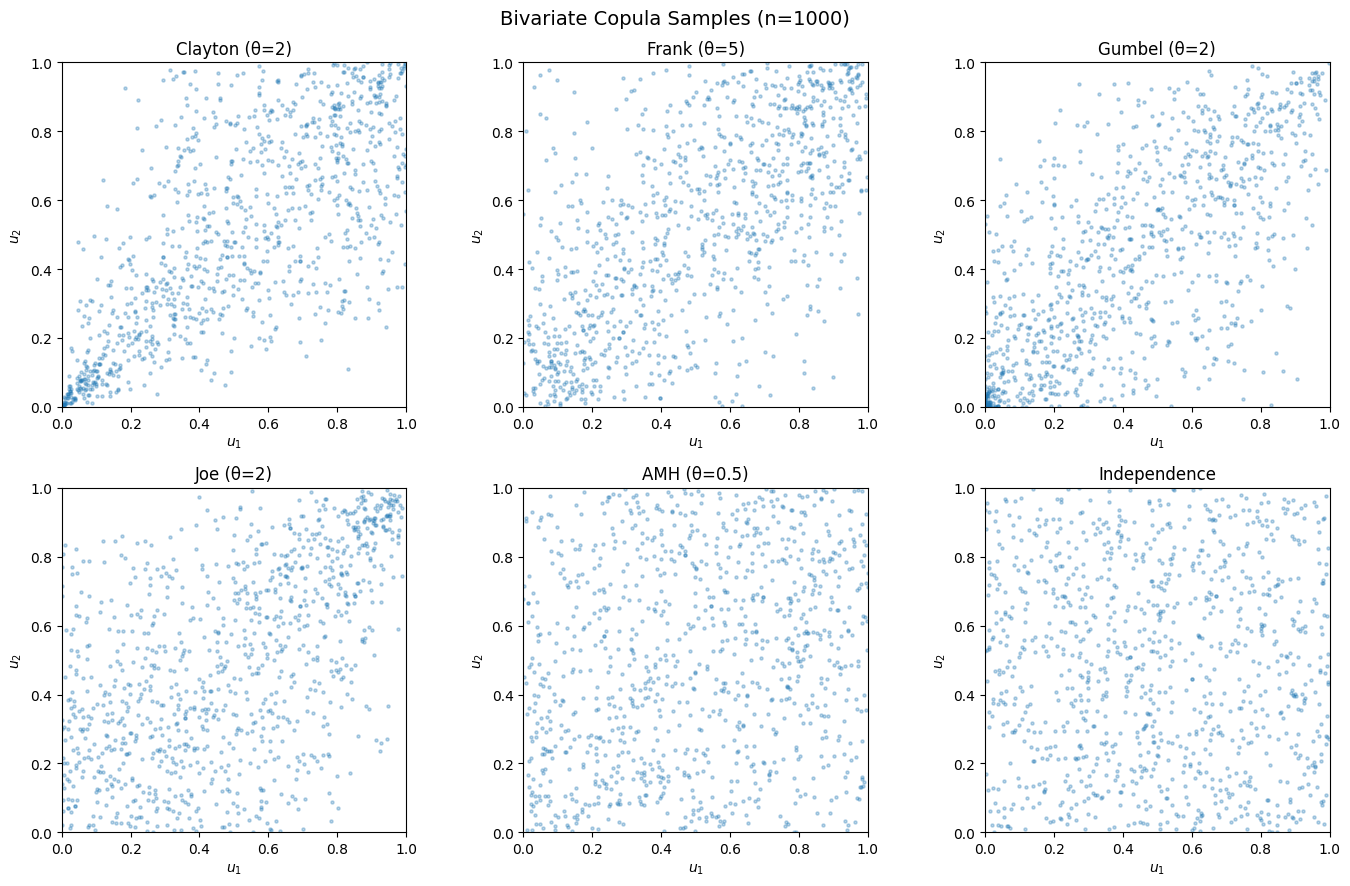

In [12]:
import matplotlib.pyplot as plt

n: int = 1000
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
fig.suptitle(f"Bivariate Copula Samples (n={n})", fontsize=14)

copulas_2d = [
    (clayton_copula, "Clayton (θ=2)"),
    (frank_copula, "Frank (θ=5)"),
    (gumbel_copula, "Gumbel (θ=2)"),
    (joe_copula, "Joe (θ=2)"),
    (amh_copula, "AMH (θ=0.5)"),
    (independence_copula, "Independence"),
]

for ax, (cop, title) in zip(axes.flat, copulas_2d):
    key, subkey = split(key)
    params = cop.example_params(dim=2)
    rvs = cop.copula_rvs(size=n, params=params, key=subkey)
    ax.scatter(rvs[:, 0], rvs[:, 1], alpha=0.3, s=5)
    ax.set_title(title)
    ax.set_xlabel("$u_1$")
    ax.set_ylabel("$u_2$")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect("equal")

plt.tight_layout()
plt.show()

## Saving and Loading Fitted Copulas

Fitted Archimedean copulas can be saved and loaded just like any other copulAX distribution.

In [ ]:
import copulax

# save the fitted Clayton copula
fitted_params.save("fitted_clayton.cpx")

# load it back
loaded = copulax.load("fitted_clayton.cpx")
print("loaded copula params:", loaded.params["copula"])

# verify identical output
original_lp = fitted_params.logpdf(sample[:5])
loaded_lp = loaded.logpdf(sample[:5])
print("logpdf matches:", jnp.allclose(original_lp, loaded_lp))

# clean up
import os
os.remove("fitted_clayton.cpx")

## Summary

This notebook demonstrated the full API for copulax's Archimedean copula family:

| Feature | Function |
|---|---|
| CDF | `copula_cdf(u, params)` |
| PDF / log-PDF | `copula_pdf(u, params)` / `copula_logpdf(u, params)` |
| Sampling | `copula_rvs(size, params, key)` |
| Full joint (Sklar) | `rvs(size, params, key)` / `logpdf(x, params)` |
| Fitting | `fit_copula(u, key)` |
| Model selection | `aic(u, params)` / `bic(u, params)` |
| Save/load | `save(path)` / `copulax.load(path)` |

All functions are **JAX-compatible** and support `jit`, `grad`, and `vmap`.